# target: cognitive status diagnosis (SCD+MCI vs. Dementia)

- Early Detection of cognitive status

### KR Font

In [1]:
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

fm.fontManager.addfont('/usr/share/fonts/truetype/nanum/NanumGothic.ttf')
plt.rcParams['font.family'] = 'NanumGothic'
plt.rcParams['axes.unicode_minus'] = False  # 마이너스(-) 기호 깨지는 것 방지

## Data Load

In [ ]:
import numpy as np
import pandas as pd
path = "../../Data/Preprocessed/scstBiomark_vaccine_naive_889_no_biomarker_filter_deidentified_merged.xlsx"
df_composite = pd.read_excel(path, sheet_name='composite_scores')

In [3]:
df_composite

,user_ID,1st_amyloid_status,1st_cognitive_status,APOE,population,sex,education_category,졸업여부,education_year,AGE,...,trailmaking_part_a_time_z_score,trailmaking_part_a_error_z_score,trailmaking_part_b_time_z_score,trailmaking_part_b_error_z_score,cst_attention_z_score,cst_language_z_score,cst_visuospatial_z_score,cst_memory_z_score,cst_executive_z_score,cst_total_z_score
0,183,음성,SCD,E3/E4,기존 455명 (과정지표 있음),여성,고등학교,졸업,12,69,...,-0.38,0.37,0.33,0.46,0.47,0.73,-0.20,-0.91,-0.02,0.04
1,248,음성,MCI,E3/E4,기존 455명 (과정지표 있음),여성,대학원(석사),졸업,18,81,...,-0.45,0.27,-0.88,-0.48,-0.18,-2.02,-1.74,-2.14,-0.79,-2.09
2,265,양성,Dementia,E3/E4,기존 455명 (과정지표 있음),여성,대학교,졸업,16,87,...,-0.22,0.49,-1.19,-1.33,0.52,0.16,-1.26,-3.44,-0.84,-1.42
3,283,양성,MCI,E3/E4,기존 455명 (과정지표 있음),여성,대학교,졸업,16,73,...,-0.56,-1.32,0.89,0.10,1.62,1.93,1.07,1.39,0.22,1.93
4,426,음성,SCD,E3/E3,기존 455명 (과정지표 있음),여성,초등학교,중퇴,4,84,...,0.52,-0.47,0.06,-0.95,1.38,-0.04,-0.33,2.06,0.33,1.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
884,8988,음성,Dementia,E2/E3,과정지표 없음(신규 포함),여성,대학교,졸업,16,77,...,0.97,0.32,-2.22,0.21,-0.02,-2.63,-1.71,-4.25,-0.78,-2.84
885,8989,음성,Dementia,E3/E3,과정지표 없음(신규 포함),남성,대학원(석사),졸업,18,78,...,-0.54,0.23,-0.82,-0.04,-0.67,-0.76,-2.16,-3.75,-0.81,-2.45
886,9079,양성,Dementia,E3/E4,과정지표 없음(신규 포함),여성,초등학교,졸업,6,73,...,-0.68,0.77,-1.42,0.44,0.96,-1.59,0.60,-3.95,-1.25,-1.51
887,9195,양성,Dementia,E3/E4,과정지표 없음(신규 포함),여성,고등학교,졸업,12,79,...,-0.61,0.56,-1.31,0.24,-0.99,-0.38,-0.22,-2.30,-1.14,-1.47


- 분포 체크

In [5]:
df_composite['1st_cognitive_status'].value_counts()

1st_cognitive_status
MCI         403
Dementia    272
SCD         214
Name: count, dtype: int64

### DROP columns

- `.py`에서 자동으로 features 에서 제외됨, 혹시 모르니 사용

In [6]:
df_composite = df_composite.drop(columns=["1st_amyloid_status", "population", "education_category", "졸업여부"], errors="ignore")

### Fill NA

In [7]:
# df 전체 컬럼에서 NaN 개수 확인
na_counts = df_composite.isna().sum()
print(na_counts[na_counts > 0])

place_recognition_z_score    1
cst_memory_z_score           1
cst_total_z_score            1
dtype: int64


In [8]:
na_fill_cols = ['place_recognition_z_score', 'cst_memory_z_score', 'cst_total_z_score']

for col in na_fill_cols:
    n_na = df_composite[col].isna().sum()
    mean_val = df_composite[col].mean()
    df_composite[col] = df_composite[col].fillna(mean_val)
    print(f"{col}: NaN {n_na}개 -> 평균값 {mean_val:.4f}로 채움")

place_recognition_z_score: NaN 1개 -> 평균값 -0.6878로 채움
cst_memory_z_score: NaN 1개 -> 평균값 -1.7328로 채움
cst_total_z_score: NaN 1개 -> 평균값 -0.8735로 채움


***

## Experiments

In [12]:
target_folder = "cognitive_status_diagnosis"

In [13]:
from pathlib import Path
import sys

try:
    # .py 파이썬 스크립트로 실행될 때
    current_dir = Path(__file__).resolve().parent
except NameError:
    # 주피터 노트북(.ipynb) 환경에서 실행될 때
    current_dir = Path.cwd()

amyloid_dir = (current_dir.parent / target_folder).resolve()
sys.path.append(str(amyloid_dir))

import data_prep, modeling, stats_tests, reporting
import run_experiments as run
import config as cfg

### preparing

In [11]:
df, covariate_column_map = data_prep.preprocess(df_composite)
df_train, df_test = data_prep.split_train_test(df)

[target] y_dementia: 0(SCD+MCI)=617, 1(Dementia)=272 (유병률 30.6%)
1st_cognitive_status
MCI         403
Dementia    272
SCD         214
[drop] 제외한 컬럼: ['user_ID']
[split] train=711, test=178
                      train  test
1st_cognitive_status             
MCI                     322    81
Dementia                218    54
SCD                     171    43


### training

In [14]:
summary_df, detail_results = run.run_all_experiments(
    df_train, df_test, covariate_column_map,
    target_folder=target_folder,
    result_folder="889_feature_selection_v4",
)


Group: All

--- M1 (n_features=18, covariates=[], n_train=711, n_test=178) ---
  [LR] 학습 중...
  [RF] 학습 중...

--- M2 (n_features=19, covariates=['sex'], n_train=711, n_test=178) ---
  [LR] 학습 중...
  [RF] 학습 중...

--- M3 (n_features=20, covariates=['sex', 'AGE'], n_train=711, n_test=178) ---
  [LR] 학습 중...
  [RF] 학습 중...

--- M4 (n_features=21, covariates=['sex', 'AGE', 'education_year'], n_train=711, n_test=178) ---
  [LR] 학습 중...
  [RF] 학습 중...

--- M5 (n_features=22, covariates=['sex', 'AGE', 'education_year', 'APOE'], n_train=711, n_test=178) ---
  [LR] 학습 중...
  [RF] 학습 중...
저장 완료: ../cognitive_status_diagnosis/results/889_feature_selection_v4/summary.csv
저장 완료: ../cognitive_status_diagnosis/results/889_feature_selection_v4/detail_results.pkl

[checkpoint] 'All' 그룹까지 결과 저장 완료 -> ../cognitive_status_diagnosis/results/889_feature_selection_v4
저장 완료: ../cognitive_status_diagnosis/results/889_feature_selection_v4/summary.csv
저장 완료: ../cognitive_status_diagnosis/results/889_feature_sel

***

## **Report**

- Caution: cognitive test $\to$ cognitive status 이므로, 성능이 좋게 나오는 것은 당연함. 참고만 할 것.


######################################################################
# Group: All
######################################################################

[All] model_type = LR

--- All/M1 [LR] CV 성능 (threshold=0.295) ---
   fold        f1       auc
0     1  0.757282  0.933425
1     2  0.822222  0.932282
2     3  0.847826  0.950139
3     4  0.729167  0.914024
4     5  0.783505  0.946911


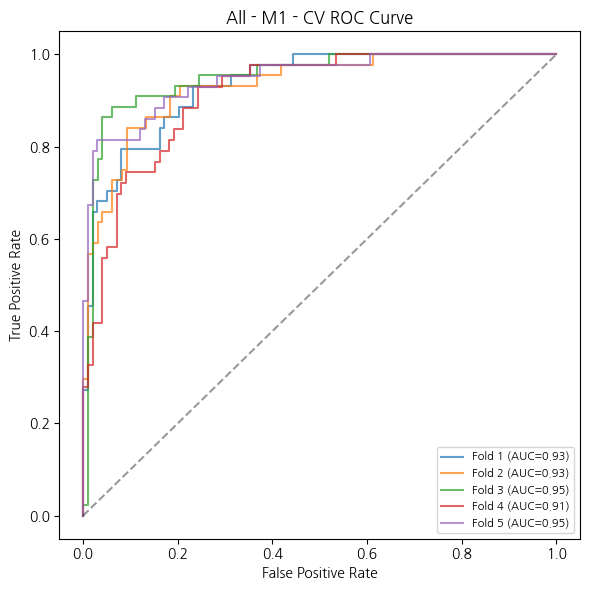

=== All/M1 [LR] train(refit) 성능 (n=711, threshold=0.295) ===
AUC : 0.945
              precision    recall  f1-score   support

           0       0.93      0.87      0.90       493
           1       0.74      0.85      0.79       218

    accuracy                           0.86       711
   macro avg       0.83      0.86      0.84       711
weighted avg       0.87      0.86      0.86       711

=== All/M1 [LR] test 성능 (n=178, threshold=0.295) ===
AUC : 0.933
              precision    recall  f1-score   support

           0       0.94      0.87      0.90       124
           1       0.75      0.87      0.80        54

    accuracy                           0.87       178
   macro avg       0.84      0.87      0.85       178
weighted avg       0.88      0.87      0.87       178


--- All/M1 [LR] 개별 OR table (Wald test) ---
                                   feature  selected_folds_by_lasso   OR_mean  \
0                         cowat_di_z_score                        5  0.791984   
1

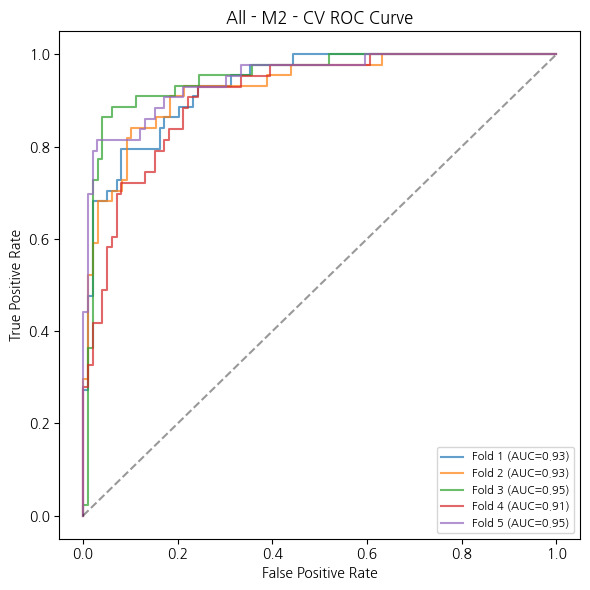

=== All/M2 [LR] train(refit) 성능 (n=711, threshold=0.285) ===
AUC : 0.945
              precision    recall  f1-score   support

           0       0.93      0.86      0.90       493
           1       0.74      0.86      0.79       218

    accuracy                           0.86       711
   macro avg       0.83      0.86      0.84       711
weighted avg       0.87      0.86      0.86       711

=== All/M2 [LR] test 성능 (n=178, threshold=0.285) ===
AUC : 0.933
              precision    recall  f1-score   support

           0       0.94      0.86      0.90       124
           1       0.73      0.87      0.80        54

    accuracy                           0.87       178
   macro avg       0.84      0.87      0.85       178
weighted avg       0.88      0.87      0.87       178


--- All/M2 [LR] 개별 OR table (Wald test) ---
                                   feature  selected_folds_by_lasso   OR_mean  \
0                         cowat_di_z_score                        5  0.793272   
1

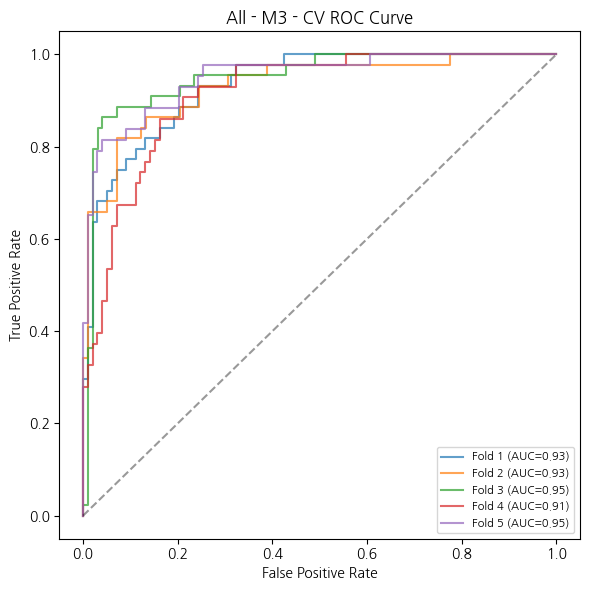

=== All/M3 [LR] train(refit) 성능 (n=711, threshold=0.294) ===
AUC : 0.946
              precision    recall  f1-score   support

           0       0.94      0.88      0.91       493
           1       0.76      0.86      0.81       218

    accuracy                           0.87       711
   macro avg       0.85      0.87      0.86       711
weighted avg       0.88      0.87      0.88       711

=== All/M3 [LR] test 성능 (n=178, threshold=0.294) ===
AUC : 0.932
              precision    recall  f1-score   support

           0       0.95      0.85      0.90       124
           1       0.72      0.91      0.80        54

    accuracy                           0.87       178
   macro avg       0.84      0.88      0.85       178
weighted avg       0.88      0.87      0.87       178


--- All/M3 [LR] 개별 OR table (Wald test) ---
                                   feature  selected_folds_by_lasso   OR_mean  \
0                                      AGE                        5  1.374954   
1

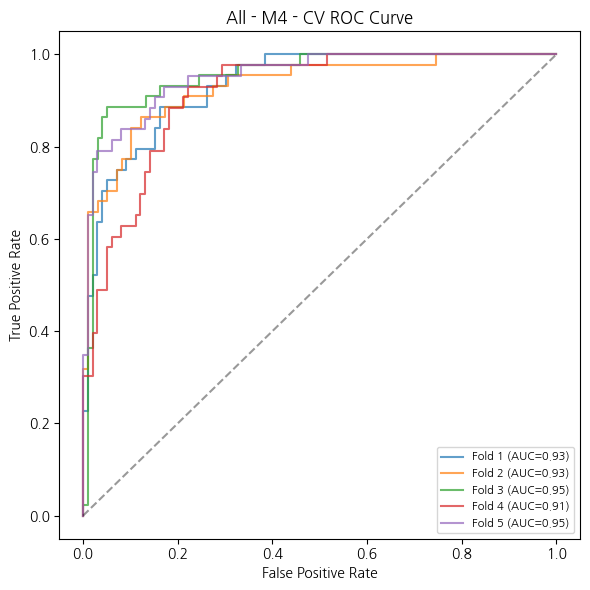

=== All/M4 [LR] train(refit) 성능 (n=711, threshold=0.303) ===
AUC : 0.948
              precision    recall  f1-score   support

           0       0.94      0.87      0.90       493
           1       0.75      0.87      0.81       218

    accuracy                           0.87       711
   macro avg       0.84      0.87      0.85       711
weighted avg       0.88      0.87      0.87       711

=== All/M4 [LR] test 성능 (n=178, threshold=0.303) ===
AUC : 0.935
              precision    recall  f1-score   support

           0       0.95      0.84      0.89       124
           1       0.71      0.91      0.80        54

    accuracy                           0.86       178
   macro avg       0.83      0.87      0.84       178
weighted avg       0.88      0.86      0.86       178


--- All/M4 [LR] 개별 OR table (Wald test) ---
                                   feature  selected_folds_by_lasso   OR_mean  \
0                                      AGE                        5  1.429894   
1

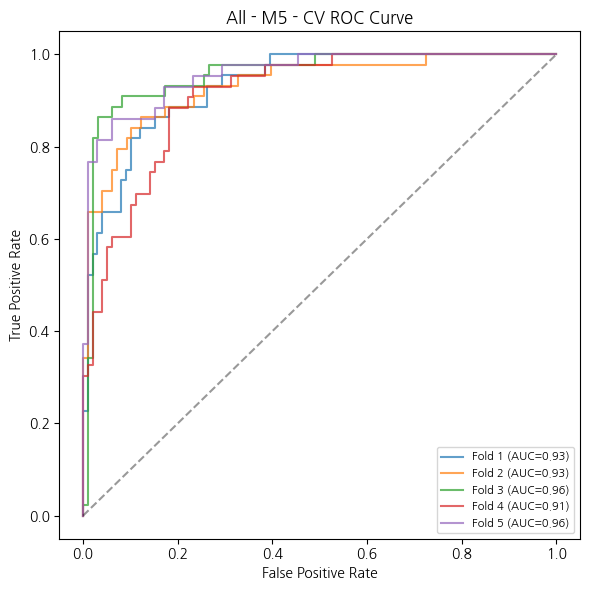

=== All/M5 [LR] train(refit) 성능 (n=711, threshold=0.341) ===
AUC : 0.948
              precision    recall  f1-score   support

           0       0.94      0.89      0.91       493
           1       0.77      0.86      0.81       218

    accuracy                           0.88       711
   macro avg       0.85      0.87      0.86       711
weighted avg       0.89      0.88      0.88       711

=== All/M5 [LR] test 성능 (n=178, threshold=0.341) ===
AUC : 0.936
              precision    recall  f1-score   support

           0       0.94      0.85      0.89       124
           1       0.71      0.87      0.78        54

    accuracy                           0.85       178
   macro avg       0.82      0.86      0.84       178
weighted avg       0.87      0.85      0.86       178


--- All/M5 [LR] 개별 OR table (Wald test) ---
                                   feature  selected_folds_by_lasso   OR_mean  \
0                                      AGE                        5  1.489082   
1

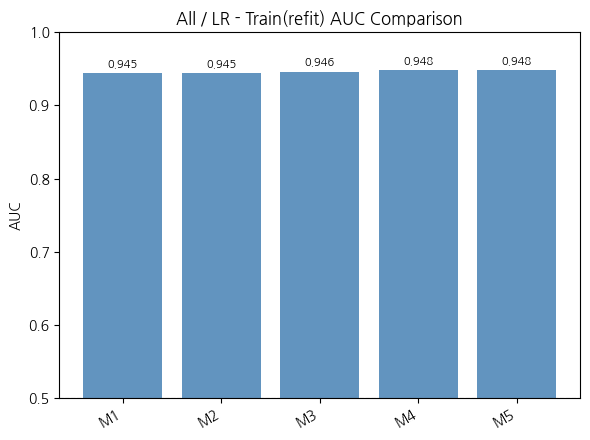

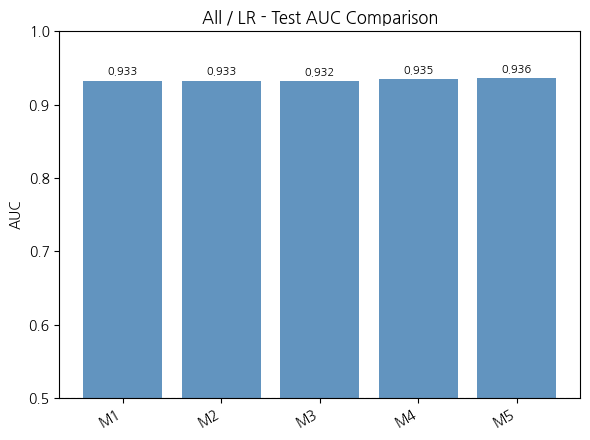


[All] model_type = RF

--- All/M1 [RF] CV 성능 (threshold=0.500) ---
   fold        f1       auc
0     1  0.791667  0.929063
1     2  0.787234  0.925557
2     3  0.851064  0.949907
3     4  0.765957  0.917548
4     5  0.783505  0.949260
=== All/M1 [RF] train(refit) 성능 (n=711, threshold=0.500) ===
AUC : 0.970
              precision    recall  f1-score   support

           0       0.96      0.89      0.92       493
           1       0.79      0.91      0.84       218

    accuracy                           0.90       711
   macro avg       0.87      0.90      0.88       711
weighted avg       0.91      0.90      0.90       711

=== All/M1 [RF] test 성능 (n=178, threshold=0.500) ===
AUC : 0.943
              precision    recall  f1-score   support

           0       0.96      0.84      0.90       124
           1       0.71      0.93      0.81        54

    accuracy                           0.87       178
   macro avg       0.84      0.88      0.85       178
weighted avg       0.89    

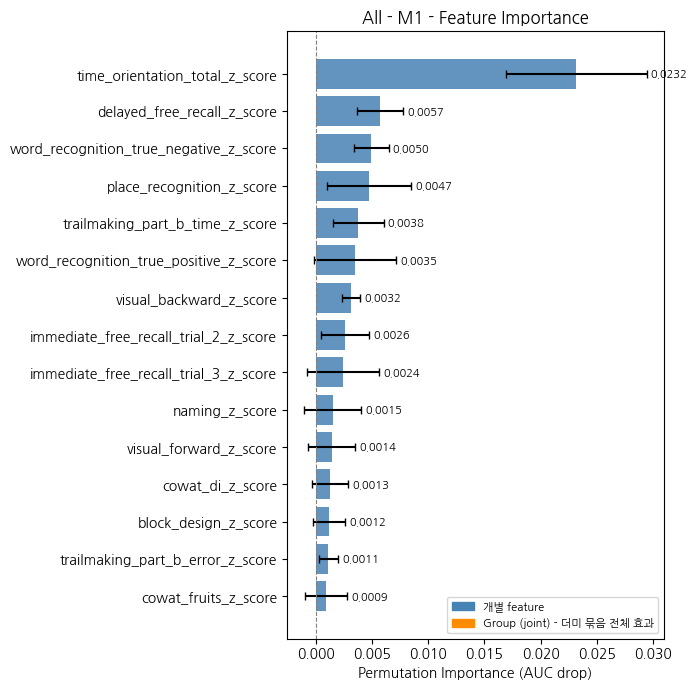

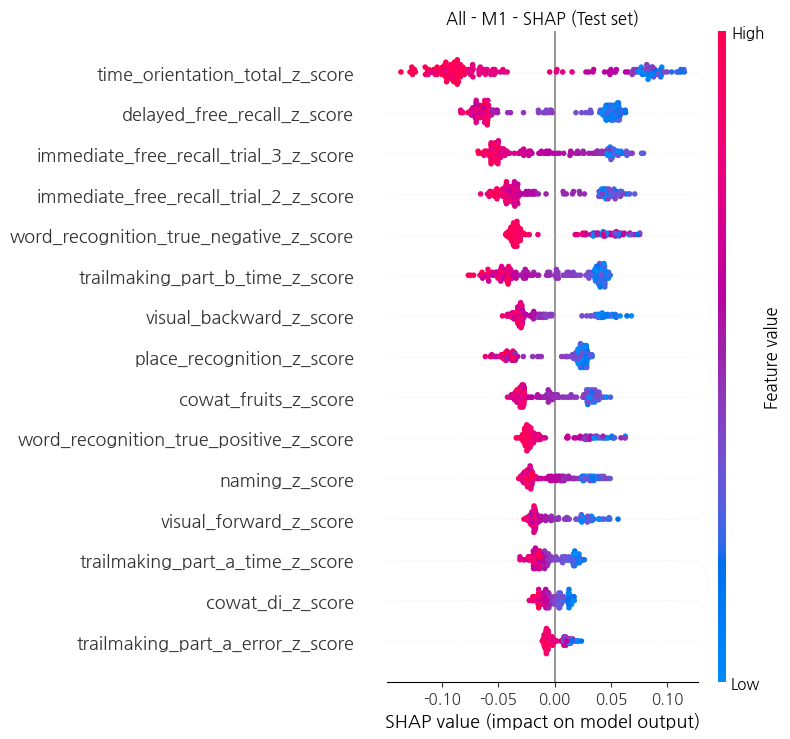


--- All/M2 [RF] CV 성능 (threshold=0.500) ---
   fold        f1       auc
0     1  0.791667  0.926079
1     2  0.774194  0.926020
2     3  0.829787  0.947124
3     4  0.757895  0.918722
4     5  0.783505  0.949730
=== All/M2 [RF] train(refit) 성능 (n=711, threshold=0.500) ===
AUC : 0.970
              precision    recall  f1-score   support

           0       0.96      0.89      0.92       493
           1       0.79      0.91      0.84       218

    accuracy                           0.90       711
   macro avg       0.87      0.90      0.88       711
weighted avg       0.91      0.90      0.90       711

=== All/M2 [RF] test 성능 (n=178, threshold=0.500) ===
AUC : 0.943
              precision    recall  f1-score   support

           0       0.96      0.84      0.90       124
           1       0.71      0.93      0.81        54

    accuracy                           0.87       178
   macro avg       0.84      0.88      0.85       178
weighted avg       0.89      0.87      0.87       

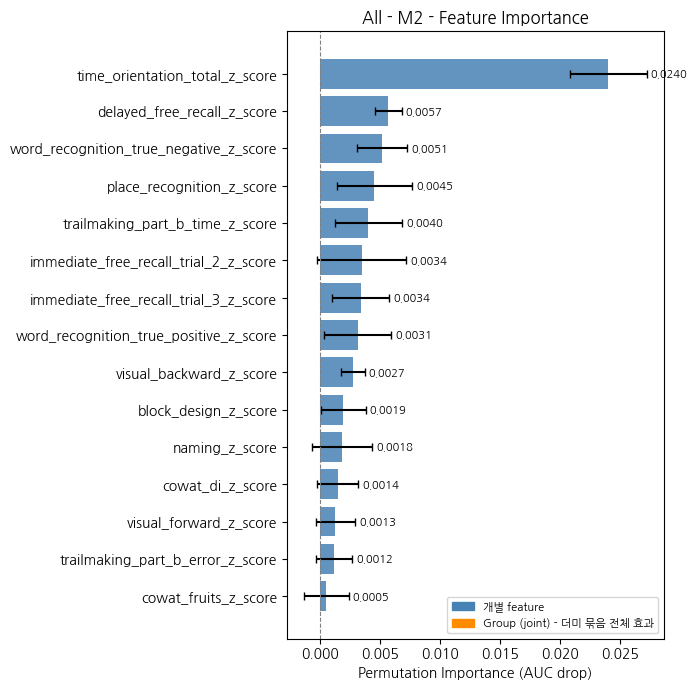

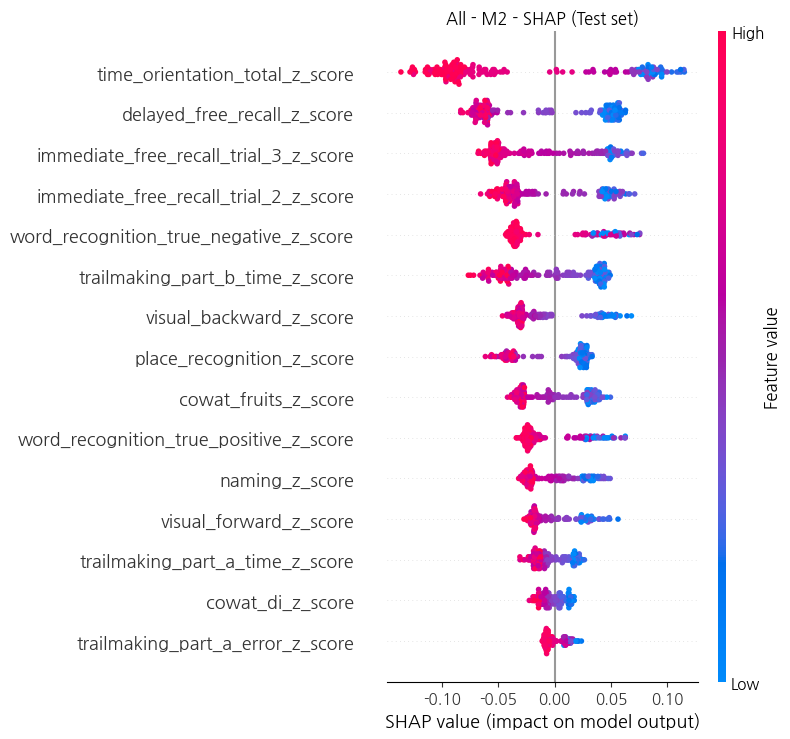


--- All/M3 [RF] CV 성능 (threshold=0.500) ---
   fold        f1       auc
0     1  0.800000  0.928834
1     2  0.800000  0.922310
2     3  0.857143  0.948748
3     4  0.765957  0.916843
4     5  0.791667  0.947616
=== All/M3 [RF] train(refit) 성능 (n=711, threshold=0.500) ===
AUC : 0.978
              precision    recall  f1-score   support

           0       0.96      0.91      0.93       493
           1       0.81      0.92      0.86       218

    accuracy                           0.91       711
   macro avg       0.89      0.91      0.90       711
weighted avg       0.92      0.91      0.91       711

=== All/M3 [RF] test 성능 (n=178, threshold=0.500) ===
AUC : 0.945
              precision    recall  f1-score   support

           0       0.95      0.86      0.90       124
           1       0.74      0.89      0.81        54

    accuracy                           0.87       178
   macro avg       0.84      0.88      0.85       178
weighted avg       0.88      0.87      0.87       

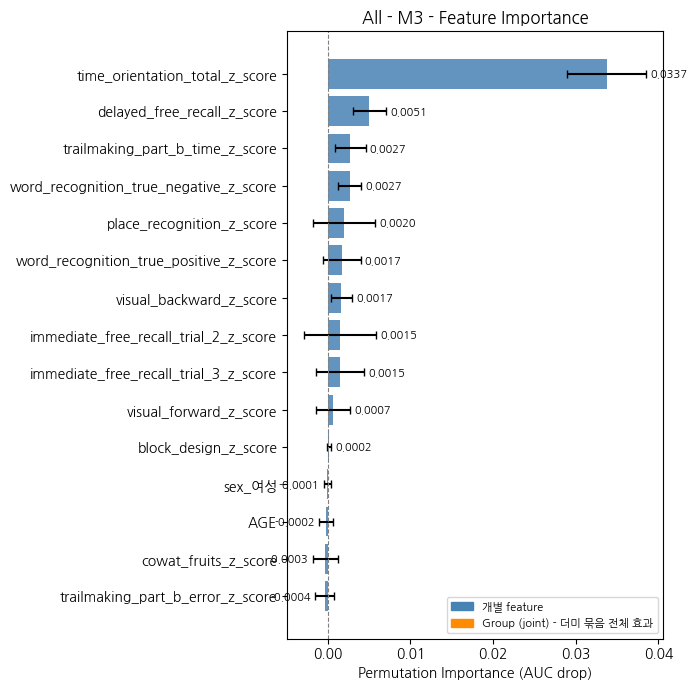

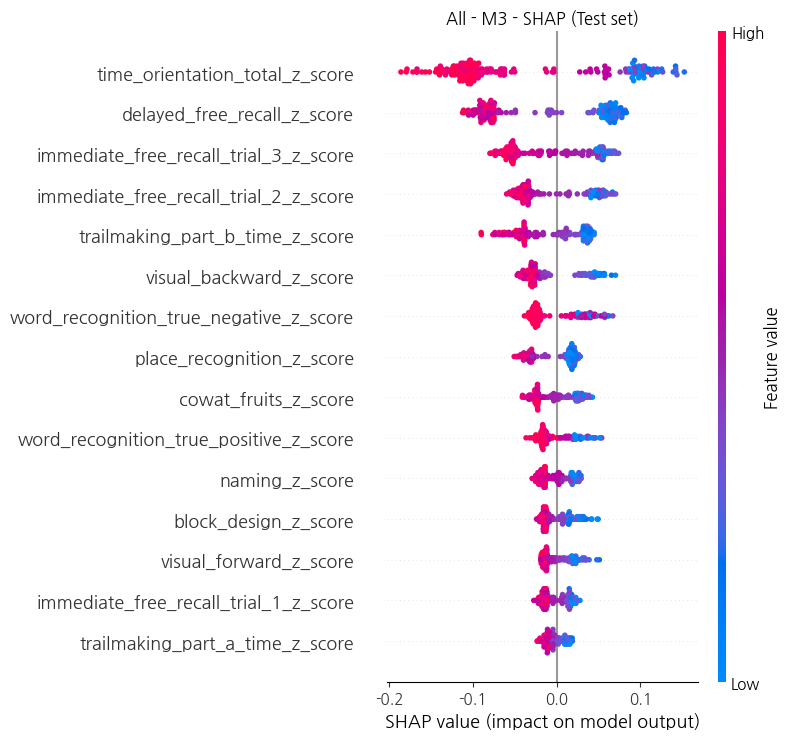


--- All/M4 [RF] CV 성능 (threshold=0.500) ---
   fold        f1       auc
0     1  0.791667  0.922865
1     2  0.800000  0.928340
2     3  0.851064  0.952690
3     4  0.757895  0.918487
4     5  0.795918  0.952314
=== All/M4 [RF] train(refit) 성능 (n=711, threshold=0.500) ===
AUC : 0.970
              precision    recall  f1-score   support

           0       0.95      0.89      0.92       493
           1       0.78      0.90      0.84       218

    accuracy                           0.89       711
   macro avg       0.87      0.90      0.88       711
weighted avg       0.90      0.89      0.89       711

=== All/M4 [RF] test 성능 (n=178, threshold=0.500) ===
AUC : 0.945
              precision    recall  f1-score   support

           0       0.97      0.84      0.90       124
           1       0.72      0.94      0.82        54

    accuracy                           0.87       178
   macro avg       0.85      0.89      0.86       178
weighted avg       0.90      0.87      0.87       

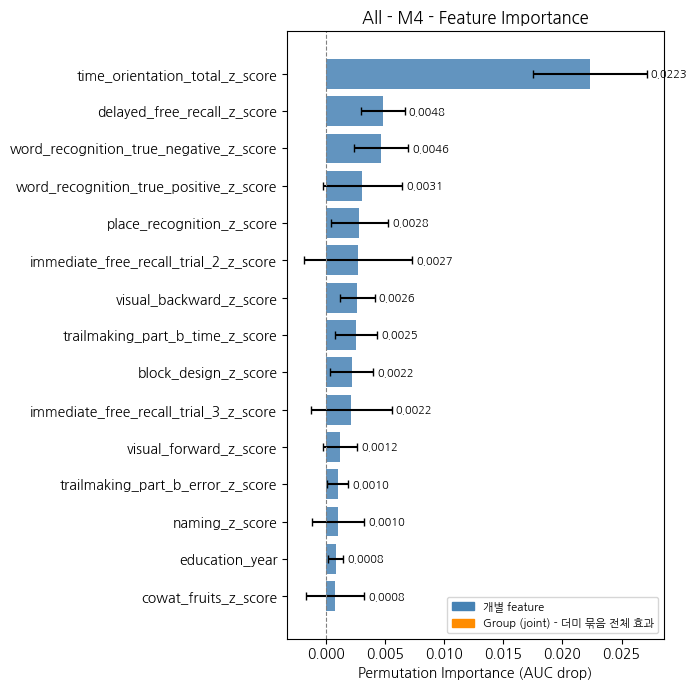

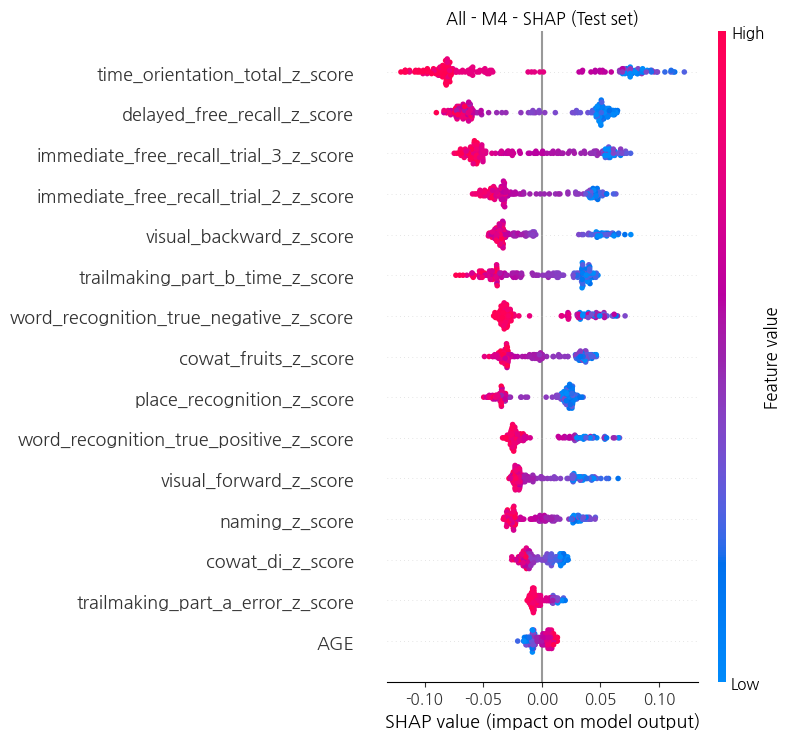


--- All/M5 [RF] CV 성능 (threshold=0.500) ---
   fold        f1       auc
0     1  0.778947  0.924931
1     2  0.800000  0.928340
2     3  0.847826  0.951994
3     4  0.770833  0.917548
4     5  0.787879  0.948086
=== All/M5 [RF] train(refit) 성능 (n=711, threshold=0.500) ===
AUC : 0.970
              precision    recall  f1-score   support

           0       0.95      0.89      0.92       493
           1       0.78      0.90      0.84       218

    accuracy                           0.89       711
   macro avg       0.87      0.89      0.88       711
weighted avg       0.90      0.89      0.89       711

=== All/M5 [RF] test 성능 (n=178, threshold=0.500) ===
AUC : 0.944
              precision    recall  f1-score   support

           0       0.96      0.85      0.91       124
           1       0.74      0.93      0.82        54

    accuracy                           0.88       178
   macro avg       0.85      0.89      0.86       178
weighted avg       0.89      0.88      0.88       

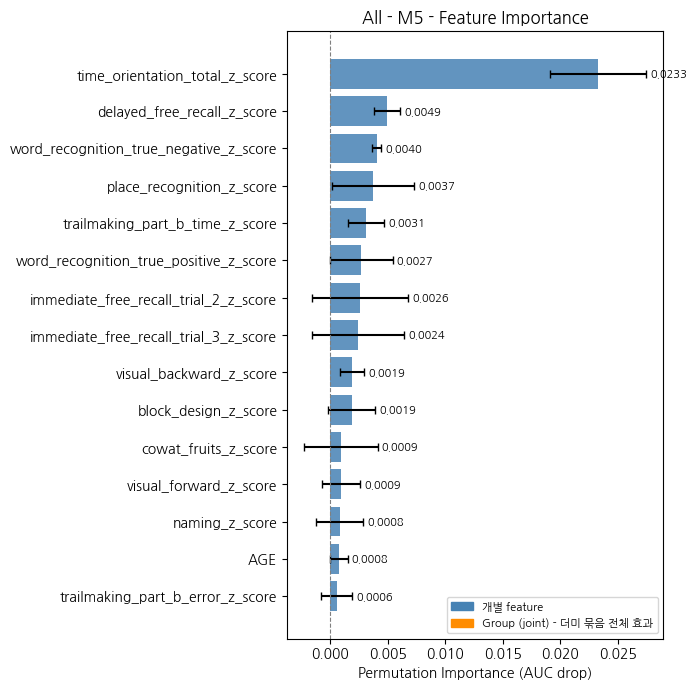

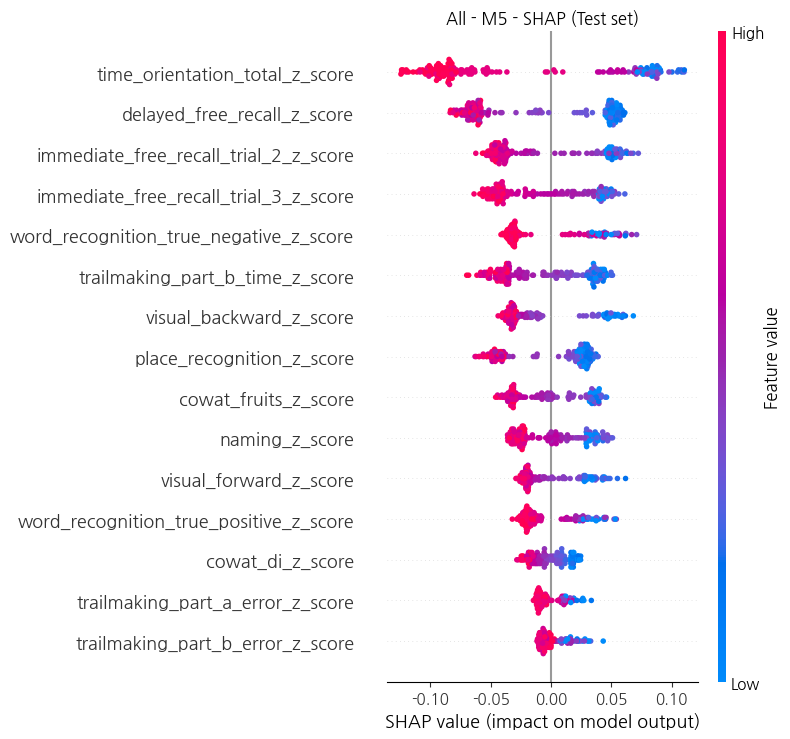

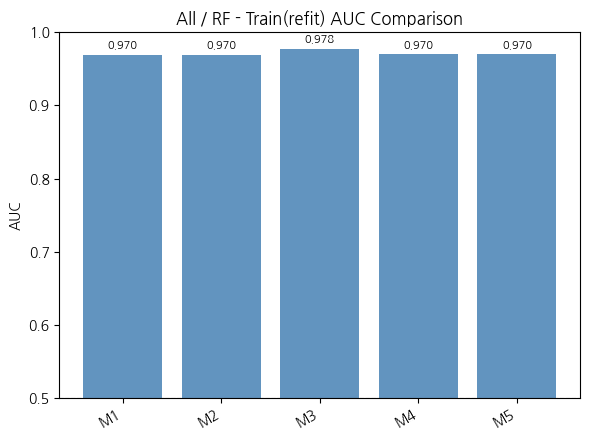

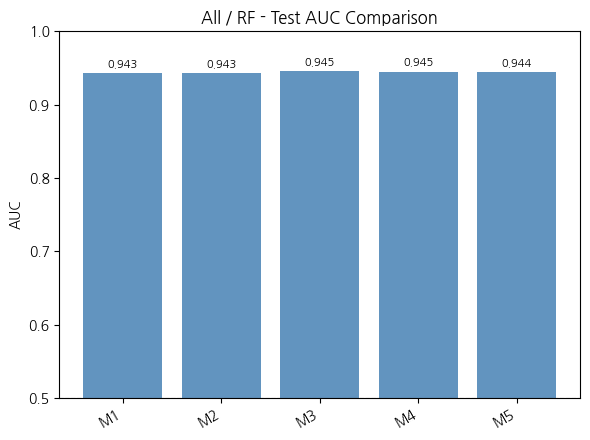

In [15]:
run.print_full_report(detail_results)